<a href="https://colab.research.google.com/github/SrilathaWeb/Data-Science-Cohort-20/blob/main/Project-4/Spotify_Project4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction

This notebook predicts Spotify song popularity using tree-based regression models.  
The workflow follows the full data science process: problem definition, solution approach, data cleaning, EDA, modeling, cross-validation, visualization, and final conclusions.

## AI Assistance Statement

This notebook was updated with AI assistance for code organization, model comparison, cross-validation, visualization, and documentation. The analysis decisions were reviewed and written in a student-friendly format.

## 1. Problem Definition

The goal of this project is to predict the **Spotify popularity score** of a song.

The target variable is:

`Popularity`

Since `Popularity` is a numeric value, this is a **regression problem**.

The project goals are:

1. Minimize the cross-validated **Root Mean Squared Error (RMSE)**.
2. Identify which features are most important in predicting popularity.
3. Avoid data leakage by removing columns that would not be known before a new song is released.

## 2. Solution Approach

The model should predict popularity for a new or unreleased song.  
Therefore, I should only use features that are available before or at release time, such as:

- Artist followers
- Audio features like danceability, energy, loudness, tempo, acousticness, etc.
- Genre
- Chord
- Release year and release month

I will avoid chart-performance columns such as `Streams`, `Highest Charting Position`, `Number of Times Charted`, and `Weeks Charted`, because those are only known after the song has already been released and charted.

## 3. Load Libraries and Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"

df_spotify = pd.read_csv(url)
df_spotify.head()

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


In [ ]:
print("Shape:", df_spotify.shape)
df_spotify.info()

Shape: (1556, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   ob

## 4. Data Cleaning

In this section, I clean column names, convert numeric-looking text columns into numeric values, convert release date into useful date features, and handle categorical columns.

Important cleaning decisions:

- Numeric columns stored as text are converted using `pd.to_numeric()`.
- Commas are removed from values like `"11,683,383"`.
- `Release Date` is converted into `Release Year` and `Release Month`.
- `Genre` and `Chord` are kept as categorical features and converted to numeric labels.
- Other text columns such as `Song Name`, `Artist`, and `Song ID` are not used as model predictors.

In [ ]:
# Clean column names
df_spotify.columns = df_spotify.columns.str.strip()

# Keep original copy for song name and artist display later
df_original = df_spotify.copy()

df_spotify.head(2)

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db


In [ ]:
# Check columns and data types before cleaning
df_spotify.dtypes

,0
Index,int64
Highest Charting Position,int64
Number of Times Charted,int64
Week of Highest Charting,object
Song Name,object
Streams,object
Artist,object
Artist Followers,object
Song ID,object
Genre,object


In [ ]:
def clean_spotify_data(df, threshold=0.8):
    '''
    Cleans Spotify data for machine learning.

    Steps:
    1. Converts numeric-looking object columns into numeric values.
    2. Converts Release Date into Release Year and Release Month.
    3. Removes leakage columns and unnecessary identifier/text columns.
    4. Keeps Genre and Chord, then label-encodes them.
    5. Drops rows with missing values in the final modeling dataset.
    '''

    df_cleaned = df.copy()
    df_cleaned.columns = df_cleaned.columns.str.strip()

    numeric_object_cols = []
    categorical_cols = []

    object_cols = df_cleaned.select_dtypes(include="object").columns
    numeric_pattern = r"^-?\d+(\.\d+)?$"

    # Identify and convert numeric-looking object columns
    for col in object_cols:
        s = df_cleaned[col].astype(str).str.strip()
        s_clean = s.str.replace(",", "", regex=False)

        not_missing = df_cleaned[col].notna()
        match_rate = s_clean[not_missing].str.match(numeric_pattern).mean()

        if match_rate >= threshold:
            numeric_object_cols.append(col)
            df_cleaned[col] = pd.to_numeric(s_clean, errors="coerce")
        else:
            categorical_cols.append(col)

    # Convert Release Date into date features
    if "Release Date" in df_cleaned.columns:
        df_cleaned["Release Date"] = pd.to_datetime(df_cleaned["Release Date"], errors="coerce")
        df_cleaned["Release Year"] = df_cleaned["Release Date"].dt.year
        df_cleaned["Release Month"] = df_cleaned["Release Date"].dt.month

        # Fill missing date features with median/mode values
        if df_cleaned["Release Year"].notna().sum() > 0:
            df_cleaned["Release Year"] = df_cleaned["Release Year"].fillna(df_cleaned["Release Year"].median())
        if df_cleaned["Release Month"].notna().sum() > 0:
            df_cleaned["Release Month"] = df_cleaned["Release Month"].fillna(df_cleaned["Release Month"].mode()[0])

    # Columns that should not be used for predicting a new song
    leakage_cols = [
        "Highest Charting Position",
        "Number of Times Charted",
        "Week of Highest Charting",
        "Streams",
        "Weeks Charted"
    ]

    id_text_cols = [
        "Index",
        "Song Name",
        "Artist",
        "Song ID",
        "Release Date"
    ]

    drop_cols = leakage_cols + id_text_cols
    df_cleaned = df_cleaned.drop(columns=drop_cols, errors="ignore")

    # Keep Genre and Chord only from categorical columns
    categorical_to_keep = ["Genre", "Chord"]

    # Drop all remaining object columns except Genre and Chord
    object_cols_after_drop = df_cleaned.select_dtypes(include="object").columns
    object_cols_to_drop = [col for col in object_cols_after_drop if col not in categorical_to_keep]
    df_cleaned = df_cleaned.drop(columns=object_cols_to_drop, errors="ignore")

    # Label encode Genre and Chord to keep them as columns instead of creating many dummy columns
    label_encoders = {}
    for col in categorical_to_keep:
        if col in df_cleaned.columns:
            encoder = LabelEncoder()
            df_cleaned[col] = df_cleaned[col].astype(str).str.strip().fillna("Unknown")
            df_cleaned[col] = encoder.fit_transform(df_cleaned[col])
            label_encoders[col] = encoder

    # Make sure all remaining columns are numeric
    for col in df_cleaned.columns:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors="coerce")

    # Drop rows with missing target or feature values
    df_cleaned = df_cleaned.dropna()

    print("Numeric object columns converted:")
    print(numeric_object_cols)

    print("\nDropped leakage/id/text columns:")
    print(drop_cols + object_cols_to_drop)

    print("\nRemaining object columns:")
    print(df_cleaned.select_dtypes(include="object").columns.tolist())

    print("\nFinal cleaned shape:", df_cleaned.shape)

    return df_cleaned, numeric_object_cols, label_encoders

In [ ]:
df_model, converted_cols, label_encoders = clean_spotify_data(df_spotify, threshold=0.8)

df_model.head()

Numeric object columns converted:
['Streams', 'Artist Followers', 'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']

Dropped leakage/id/text columns:
['Highest Charting Position', 'Number of Times Charted', 'Week of Highest Charting', 'Streams', 'Weeks Charted', 'Index', 'Song Name', 'Artist', 'Song ID', 'Release Date']

Remaining object columns:
[]

Final cleaned shape: (1545, 15)


,Artist Followers,Genre,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord,Release Year,Release Month
0,3377762.0,277,100.0,0.714,0.800,-4.808,0.0504,0.1270,0.3590,134.002,211560.0,0.589,3,2017.0,12.0
1,2230022.0,64,99.0,0.591,0.764,-5.484,0.0483,0.0383,0.1030,169.928,141806.0,0.478,5,2021.0,7.0
2,6266514.0,365,99.0,0.563,0.664,-5.044,0.1540,0.3350,0.0849,166.928,178147.0,0.688,1,2021.0,5.0
3,83293380.0,364,98.0,0.808,0.897,-3.712,0.0348,0.0469,0.3640,126.026,231041.0,0.591,3,2021.0,6.0
4,5473565.0,313,96.0,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000.0,0.894,7,2021.0,7.0


In [ ]:
# Verify no missing values remain
df_model.isna().sum()[df_model.isna().sum() > 0]

,0


In [ ]:
# Verify all columns are numeric
df_model.dtypes

,0
Artist Followers,float64
Genre,int64
Popularity,float64
Danceability,float64
Energy,float64
Loudness,float64
Speechiness,float64
Acousticness,float64
Liveness,float64
Tempo,float64


## 5. Exploratory Data Analysis (EDA)

EDA helps understand the target variable and the cleaned features before modeling.

In [ ]:
# Summary statistics
df_model.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Artist Followers,1545.0,1.471690e+07,1.667579e+07,4883.000000,2.123734e+06,6.852509e+06,2.269875e+07,8.333778e+07
Genre,1545.0,2.231379e+02,1.125356e+02,1.000000,1.140000e+02,2.220000e+02,3.180000e+02,3.940000e+02
Popularity,1545.0,7.008932e+01,1.582403e+01,0.000000,6.500000e+01,7.300000e+01,8.000000e+01,1.000000e+02
Danceability,1545.0,6.899968e-01,1.424440e-01,0.150000,5.990000e-01,7.070000e-01,7.960000e-01,9.800000e-01
Energy,1545.0,6.334951e-01,1.615770e-01,0.054000,5.320000e-01,6.420000e-01,7.520000e-01,9.700000e-01
Loudness,1545.0,-6.348474e+00,2.509281e+00,-25.166000,-7.491000e+00,-5.990000e+00,-4.711000e+00,1.509000e+00
Speechiness,1545.0,1.236557e-01,1.103827e-01,0.023200,4.560000e-02,7.650000e-02,1.650000e-01,8.840000e-01
Acousticness,1545.0,2.486945e-01,2.503259e-01,0.000025,4.850000e-02,1.610000e-01,3.880000e-01,9.940000e-01
Liveness,1545.0,1.812024e-01,1.440710e-01,0.019700,9.660000e-02,1.240000e-01,2.170000e-01,9.620000e-01
Tempo,1545.0,1.228110e+02,2.959109e+01,46.718000,9.796000e+01,1.220120e+02,1.438600e+02,2.052720e+02


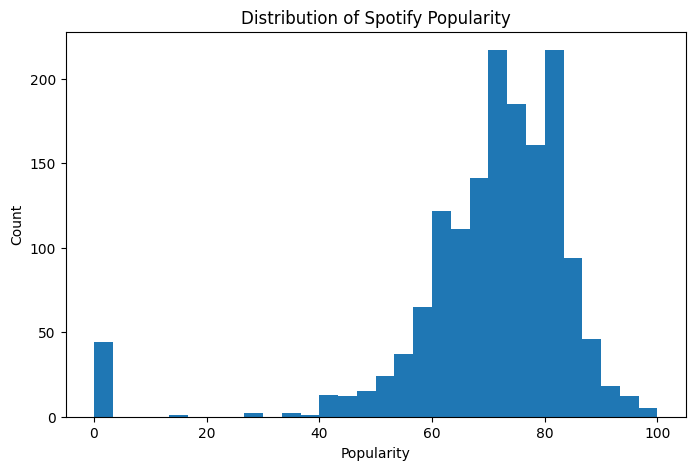

In [ ]:
# Target distribution
plt.figure(figsize=(8, 5))
plt.hist(df_model["Popularity"], bins=30)
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.title("Distribution of Spotify Popularity")
plt.show()

In [ ]:
# Correlation with target
correlations = df_model.corr(numeric_only=True)["Popularity"].sort_values(ascending=False)
correlations

,Popularity
Popularity,1.000000
Loudness,0.158767
Artist Followers,0.104358
Energy,0.094691
Release Year,0.083089
Duration (ms),0.082096
Chord,0.045788
Danceability,0.028435
Valence,-0.000953
Tempo,-0.024951


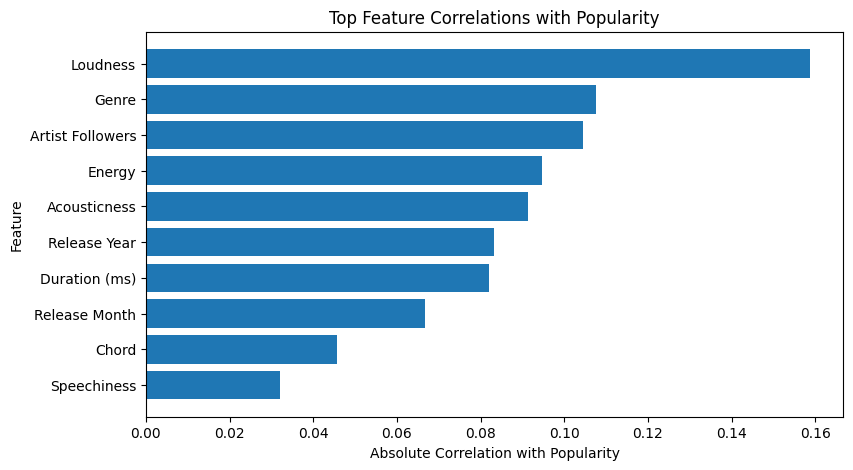

In [ ]:
# Top correlations with Popularity
top_corr = correlations.drop("Popularity").abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(top_corr.index[::-1], top_corr.values[::-1])
plt.xlabel("Absolute Correlation with Popularity")
plt.ylabel("Feature")
plt.title("Top Feature Correlations with Popularity")
plt.show()

## 6. Feature Selection

The target is `Popularity`.

The model features are all remaining cleaned numeric columns except `Popularity`.

I removed leakage columns because they would not be available before a new song is released.

In [ ]:
X = df_model.drop(columns=["Popularity"])
y = df_model["Popularity"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features used:")
print(X.columns.tolist())

X shape: (1545, 14)
y shape: (1545,)
Features used:
['Artist Followers', 'Genre', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'Chord', 'Release Year', 'Release Month']


In [ ]:
# Keep song names and artists for final prediction reporting.
# df_model kept the original row index, so we can align metadata using df_model.index.
song_names = df_original.loc[df_model.index, "Song Name"]
artists = df_original.loc[df_model.index, "Artist"]

print(song_names.head())
print(artists.head())

0                              Beggin'
1            STAY (with Justin Bieber)
2                             good 4 u
3                           Bad Habits
4    INDUSTRY BABY (feat. Jack Harlow)
Name: Song Name, dtype: object
0          Måneskin
1     The Kid LAROI
2    Olivia Rodrigo
3        Ed Sheeran
4         Lil Nas X
Name: Artist, dtype: object


## 7. Train/Test Split

The dataset is split into training and testing data.

The model learns from the training data, and final performance is checked on the test data.

In [ ]:
X_train, X_test, y_train, y_test, song_train, song_test, artist_train, artist_test = train_test_split(
    X,
    y,
    song_names,
    artists,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1236
Testing rows: 309


## 8. Model Training

I trained three tree-based regression models:

1. Decision Tree Regressor
2. Random Forest Regressor
3. Gradient Boosting Regressor

These models are appropriate because the project requires tree-based regression techniques.

In [ ]:
models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

## 9. Cross Validation

Cross-validation gives a more reliable estimate of model performance than a single train/test split.

RMSE is used as the main evaluation metric. Lower RMSE means better prediction accuracy.

In [ ]:
def cross_validated_rmse(model, X_data, y_data, n_splits=5):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    neg_mse_scores = cross_val_score(
        model,
        X_data,
        y_data,
        scoring="neg_mean_squared_error",
        cv=kfold
    )

    rmse_scores = np.sqrt(-neg_mse_scores)
    return rmse_scores

In [ ]:
cv_results = []

for model_name, model in models.items():
    rmse_scores = cross_validated_rmse(model, X_train, y_train, n_splits=5)

    cv_results.append({
        "Model": model_name,
        "Mean CV RMSE": rmse_scores.mean(),
        "Std CV RMSE": rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Mean CV RMSE")
cv_results_df

,Model,Mean CV RMSE,Std CV RMSE
2,Gradient Boosting,8.420867,0.591982
1,Random Forest,8.834412,1.034106
0,Decision Tree,9.574328,1.232573


## 10. Model Comparison Using Test Data

After cross-validation, I also compare the three models on the held-out test set.

In [ ]:
test_results = []
test_predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    test_results.append({
        "Model": model_name,
        "Test RMSE": rmse,
        "Test R2": r2
    })

    test_predictions[model_name] = y_pred

test_results_df = pd.DataFrame(test_results).sort_values("Test RMSE")
test_results_df

,Model,Test RMSE,Test R2
1,Random Forest,8.288629,0.744522
2,Gradient Boosting,8.350833,0.740673
0,Decision Tree,9.275444,0.680069


In [ ]:
# Choose best model based on cross-validated RMSE
best_model_name = cv_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_predictions = best_model.predict(X_test)

print("Best model based on CV RMSE:", best_model_name)
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, best_predictions)), 3))
print("Test R2:", round(r2_score(y_test, best_predictions), 3))

Best model based on CV RMSE: Gradient Boosting
Test RMSE: 8.351
Test R2: 0.741


## 11. Visualization

This section shows visual comparisons of model performance and predictions.

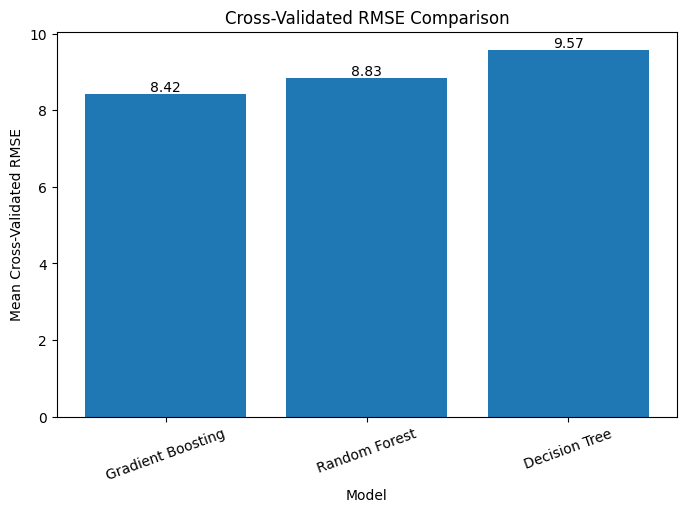

In [ ]:
# Cross-validated RMSE comparison chart
plt.figure(figsize=(8, 5))
bars = plt.bar(cv_results_df["Model"], cv_results_df["Mean CV RMSE"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        round(height, 2),
        ha="center",
        va="bottom"
    )

plt.xlabel("Model")
plt.ylabel("Mean Cross-Validated RMSE")
plt.title("Cross-Validated RMSE Comparison")
plt.xticks(rotation=20)
plt.show()

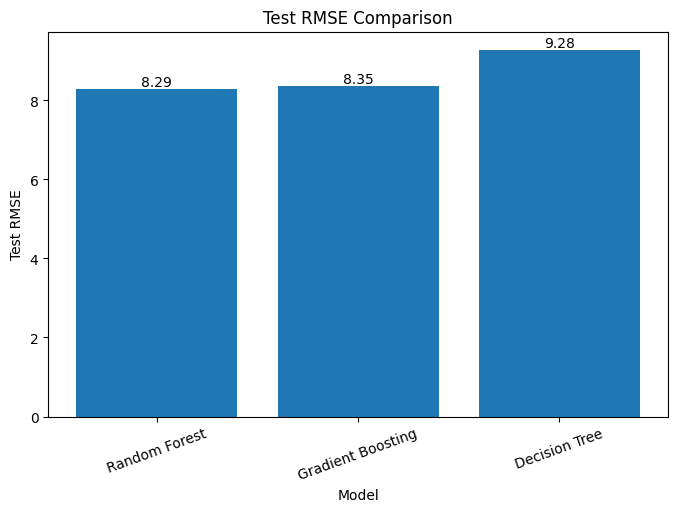

In [ ]:
# Test RMSE comparison chart
plt.figure(figsize=(8, 5))
bars = plt.bar(test_results_df["Model"], test_results_df["Test RMSE"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        round(height, 2),
        ha="center",
        va="bottom"
    )

plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Test RMSE Comparison")
plt.xticks(rotation=20)
plt.show()

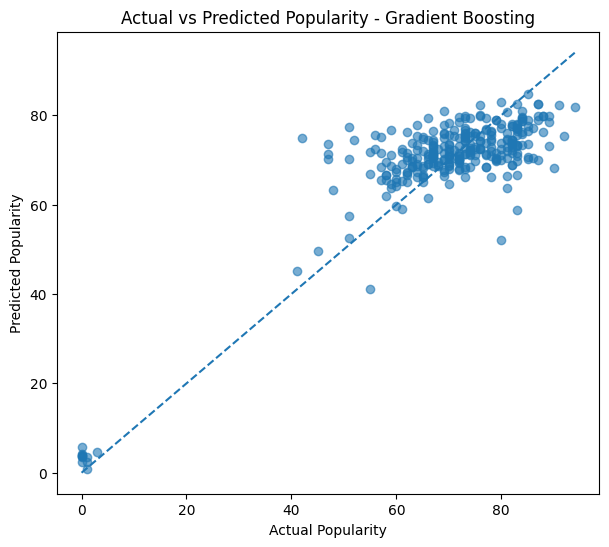

In [ ]:
# Actual vs predicted plot for best model
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.6)

lo = min(y_test.min(), best_predictions.min())
hi = max(y_test.max(), best_predictions.max())

plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title(f"Actual vs Predicted Popularity - {best_model_name}")
plt.show()

## 12. Prediction Results

RMSE tells us the overall model error, but the prediction table shows the actual predicted popularity score for each song in the test set.

In [ ]:
prediction_results = pd.DataFrame({
    "Song Name": song_test.values,
    "Artist": artist_test.values,
    "Actual Popularity": y_test.values,
    "Predicted Popularity": best_predictions
})

prediction_results["Predicted Popularity"] = prediction_results["Predicted Popularity"].round(2)
prediction_results["Error"] = (
    prediction_results["Actual Popularity"] - prediction_results["Predicted Popularity"]
).abs().round(2)

prediction_results.head(10)

,Song Name,Artist,Actual Popularity,Predicted Popularity,Error
0,Once A Day,Mac Miller,61.0,59.03,1.97
1,Moonlight,XXXTENTACION,83.0,76.37,6.63
2,Repeat After Me (Interlude),The Weeknd,63.0,70.49,7.49
3,CLOUDS,NF,69.0,73.18,4.18
4,P2,Lil Uzi Vert,73.0,68.38,4.62
5,FRANCHISE (feat. Young Thug & M.I.A.),Travis Scott,74.0,72.57,1.43
6,Diamonds (with Normani),Megan Thee Stallion,58.0,69.54,11.54
7,Up All Night,Khalid,69.0,75.83,6.83
8,Por Primera Vez,"Camilo, Evaluna Montaner",70.0,69.41,0.59
9,EN CASITA,"Bad Bunny, Gabriela",62.0,70.61,8.61


In [ ]:
# Songs with highest predicted popularity
top_predicted_songs = prediction_results.sort_values(
    by="Predicted Popularity",
    ascending=False
)

top_predicted_songs.head(10)

,Song Name,Artist,Actual Popularity,Predicted Popularity,Error
199,"No Me Conocen (Remix) [con DUKI, Rei & Tiago PZK]",BANDIDO,85.0,84.65,0.35
114,Little Bit of Love,Tom Grennan,80.0,82.92,2.92
97,Sobrio,Maluma,87.0,82.61,4.39
66,Botella Tras Botella,"Gera MX, Christian Nodal",87.0,82.59,4.41
117,Photograph,Ed Sheeran,83.0,82.57,0.43
37,Tu Veneno,J Balvin,76.0,82.40,6.40
225,favorite crime,Olivia Rodrigo,91.0,82.34,8.66
166,traitor,Olivia Rodrigo,94.0,81.96,12.04
147,Tout l'univers,Gjon's Tears,69.0,80.94,11.94
235,Aloha,"Maluma, Beéle, Rauw Alejandro, Mambo Kingz, DJ...",84.0,80.93,3.07


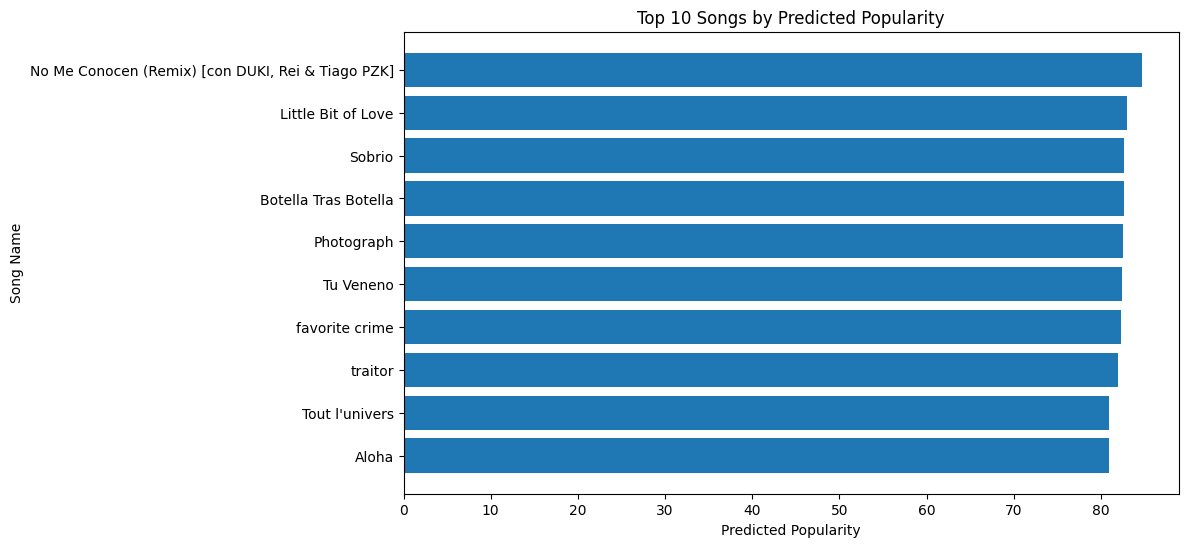

In [ ]:
# Top 10 predicted songs visualization
top_10 = top_predicted_songs.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10["Song Name"], top_10["Predicted Popularity"])
plt.gca().invert_yaxis()
plt.xlabel("Predicted Popularity")
plt.ylabel("Song Name")
plt.title("Top 10 Songs by Predicted Popularity")
plt.show()

In [ ]:
# Best predictions with smallest error
prediction_results.sort_values("Error").head(10)

,Song Name,Artist,Actual Popularity,Predicted Popularity,Error
25,Petrouchka (feat. PLK),Soso Maness,79.0,78.96,0.04
98,Many Men,"21 Savage, Metro Boomin",65.0,65.09,0.09
279,Make You Mine,PUBLIC,77.0,76.88,0.12
38,Fan de Tus Fotos,"Nicky Jam, Romeo Santos",79.0,78.87,0.13
171,@ MEH,Playboi Carti,1.0,0.84,0.16
105,THE BADDEST,"K/DA, (G)I-DLE, Wolftyla, Bea Miller, League o...",70.0,70.17,0.17
115,Hallelujah,Pentatonix,60.0,59.79,0.21
122,Lieben wir,Shirin David,77.0,76.76,0.24
293,Not Shy,ITZY,73.0,72.75,0.25
102,Despeinada,"Ozuna, Camilo",75.0,75.27,0.27


## 13. Feature Importance

Feature importance helps explain which variables had the strongest influence on the prediction.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
1,Genre,0.419053
0,Artist Followers,0.305276
12,Release Year,0.147498
4,Loudness,0.018447
13,Release Month,0.017406
10,Valence,0.015784
5,Speechiness,0.015313
8,Tempo,0.014423
7,Liveness,0.013330
9,Duration (ms),0.010316


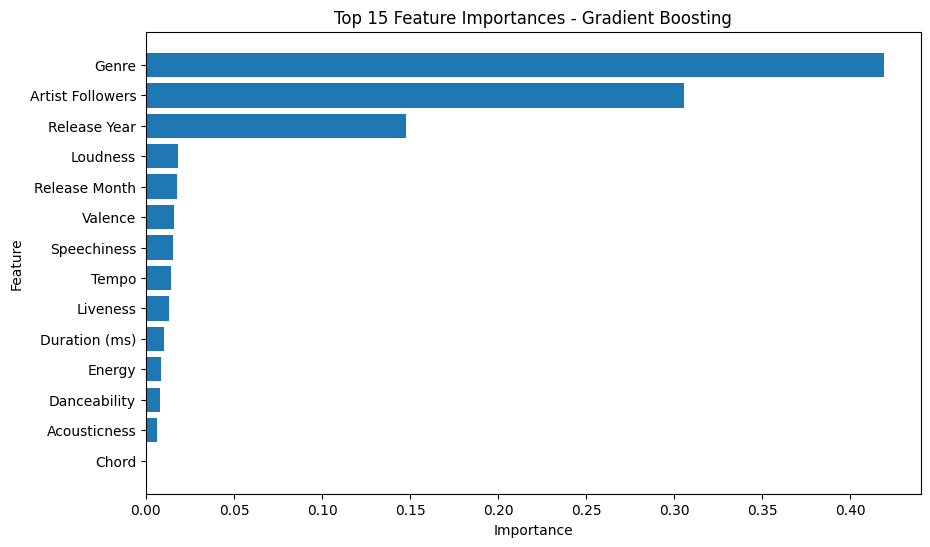

In [ ]:
top_features = feature_importance.head(15).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top 15 Feature Importances - {best_model_name}")
plt.show()

## 14. Optional Hyperparameter Tuning

This section tunes Gradient Boosting because boosting is often strong for tabular regression problems.

The goal is to improve RMSE while avoiding overfitting.

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

tuned_gb = gb_grid.best_estimator_
tuned_pred = tuned_gb.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
print("Tuned Gradient Boosting Test RMSE:", round(tuned_rmse, 3))
print("Tuned Gradient Boosting Test R2:", round(tuned_r2, 3))

Best Gradient Boosting Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Tuned Gradient Boosting Test RMSE: 8.351
Tuned Gradient Boosting Test R2: 0.741


## 15. Conclusion

In this project, I predicted Spotify song popularity using tree-based regression models.

The target variable was `Popularity`, so this was a regression problem. I removed chart-related columns such as `Highest Charting Position`, `Number of Times Charted`, `Streams`, and `Weeks Charted` because those values would not be available before a new song is released.

I trained and compared three models: Decision Tree, Random Forest, and Gradient Boosting. I used cross-validated RMSE to evaluate model performance and selected the model with the lowest RMSE as the best model.

I also created a prediction table showing each test song's actual popularity and predicted popularity. Finally, I used feature importance to identify the most influential predictors.